# Experimento A — Jerarquía de Memoria
**Objetivo:** Comparar tiempos de operaciones en memoria RAM vs disco para distintos tamaños de datos, calcular throughput y analizar diferencias de rendimiento entre niveles de la jerarquía de memoria.

###  1. Importación de librerías

In [1]:
import platform # Obtiene información del sistema operativo y procesador
import psutil # Lee métricas de hardware: RAM, CPU, disco en tiempo real
import numpy as np
import pandas as pd
import os          # manejo de rutas y archivos
import time        # medir tiempos de ejecucion
import matplotlib.pyplot as plt  # para graficar
from pathlib import Path

### 2. Configuración del entorno experimental

In [2]:
datos_dir = Path("../datos")
vis_dir = Path("../visualizaciones")
datos_dir.mkdir(exist_ok=True)
vis_dir.mkdir(exist_ok=True)

In [3]:
# Definimos tamaños de datos en MB (mínimo 5 como pide el enunciado)
sizes_mb = [10, 50, 100, 200, 500,1000,2000,5000]
# Número de repeticiones por experimento (para promediar)
repetitions = 3
# Tipo de dato (float64 = 8 bytes)
dtype = np.float64
bytes_per_element = np.dtype(dtype).itemsize

### 3  . Funciones auxiliares

In [4]:
# Función para convertir MB a número de elementos del arreglo
def mb_to_elements(size_mb, bytes_per_element=8):
    return (size_mb * 1024 * 1024) // bytes_per_element

# Función para calcular throughput (MB/s)
def throughput_mb_s(size_mb, elapsed_time):
    if elapsed_time == 0:
        return np.nan
    return size_mb / elapsed_time

### 4. Ejecución del benchmark (RAM vs Disco)

In [5]:
# Lista donde guardaremos resultados
results = []
# Iteramos sobre cada tamaño
for size_mb in sizes_mb:
    print(f"\nProbando tamaño: {size_mb} MB")
    # Convertimos tamaño a número de elementos
    n_elements = mb_to_elements(size_mb, bytes_per_element)
    # Ruta del archivo en disco
    file_path = datos_dir / f"array_{size_mb}MB.npy"
    # Listas para guardar tiempos
    ram_write_times = []
    ram_read_times = []
    disk_write_times = []
    disk_read_times = []
    # Repetimos el experimento
    for rep in range(repetitions):
        
        # Generamos datos aleatorios
        data = np.random.rand(n_elements).astype(dtype)
        # =========================
        # RAM - Escritura (copia)
        # =========================
        start = time.perf_counter()
        data_copy = data.copy()
        end = time.perf_counter()
        ram_write_times.append(end - start)
        # =========================
        # RAM - Lectura (uso datos)
        # =========================
        start = time.perf_counter()
        _ = np.sum(data_copy)  # fuerza acceso real
        end = time.perf_counter()
        ram_read_times.append(end - start)
        # =========================
        # Disco - Escritura
        # =========================
        start = time.perf_counter()
        np.save(file_path, data)
        end = time.perf_counter()
        disk_write_times.append(end - start)
        # =========================
        # Disco - Lectura
        # =========================
        start = time.perf_counter()
        loaded = np.load(file_path)
        _ = np.sum(loaded)  # fuerza acceso
        end = time.perf_counter()
        disk_read_times.append(end - start)
    # Promedios
    avg_ram_write = np.mean(ram_write_times)
    avg_ram_read = np.mean(ram_read_times)
    avg_disk_write = np.mean(disk_write_times)
    avg_disk_read = np.mean(disk_read_times)
    # Guardamos resultados
    results.append({
    "tamano_mb": size_mb,
    "tiempo_escritura_ram_s": avg_ram_write,
    "tiempo_lectura_ram_s": avg_ram_read,
    "tiempo_escritura_disco_s": avg_disk_write,
    "tiempo_lectura_disco_s": avg_disk_read,
    "throughput_escritura_ram_mb_s": throughput_mb_s(size_mb, avg_ram_write),
    "throughput_lectura_ram_mb_s": throughput_mb_s(size_mb, avg_ram_read),
    "throughput_escritura_disco_mb_s": throughput_mb_s(size_mb, avg_disk_write),
    "throughput_lectura_disco_mb_s": throughput_mb_s(size_mb, avg_disk_read),
})


Probando tamaño: 10 MB

Probando tamaño: 50 MB

Probando tamaño: 100 MB

Probando tamaño: 200 MB

Probando tamaño: 500 MB

Probando tamaño: 1000 MB

Probando tamaño: 2000 MB

Probando tamaño: 5000 MB


### 5. Guardar resultados en CSV

In [6]:
# Convertimos resultados a DataFrame
df_results = pd.DataFrame(results)

# Guardamos en archivo CSV
df_results.to_csv(datos_dir / "resultados_experimento_a.csv", index=False)# Mostramos resultados
print("\n=== Resultados ===")
df_results


=== Resultados ===


,tamano_mb,tiempo_escritura_ram_s,tiempo_lectura_ram_s,tiempo_escritura_disco_s,tiempo_lectura_disco_s,throughput_escritura_ram_mb_s,throughput_lectura_ram_mb_s,throughput_escritura_disco_mb_s,throughput_lectura_disco_mb_s
0,10,0.001173,0.000749,0.003113,0.006617,8528.299741,13358.268769,3212.335368,1511.228427
1,50,0.005567,0.005055,0.044257,0.020095,8980.799052,9891.327284,1129.770739,2488.222414
2,100,0.011362,0.010022,0.074396,0.035876,8801.448132,9977.616879,1344.150459,2787.373569
3,200,0.023148,0.020952,0.124818,0.063865,8640.229484,9545.415496,1602.336420,3131.581214
4,500,0.057370,0.055297,0.315118,0.157352,8715.396969,9042.010991,1586.707202,3177.583041
5,1000,0.112034,0.114651,0.678545,0.334592,8925.856481,8722.086416,1473.740957,2988.718484
6,2000,0.252777,0.245106,1.792904,0.766693,7912.112257,8159.724985,1115.508922,2608.604805
7,5000,0.800441,0.410688,5.217866,3.048162,6246.555285,12174.704082,958.246075,1640.332585


### 6. Visualización: Tiempos

In [ ]:
# Gráfico de tiempos de ejecución

plt.figure(figsize=(10, 6))

plt.plot(df_results["tamano_mb"], df_results["tiempo_escritura_ram_s"], marker="o", label="RAM escritura")
plt.plot(df_results["tamano_mb"], df_results["tiempo_lectura_ram_s"], marker="o", label="RAM lectura")
plt.plot(df_results["tamano_mb"], df_results["tiempo_escritura_disco_s"], marker="o", label="Disco escritura")
plt.plot(df_results["tamano_mb"], df_results["tiempo_lectura_disco_s"], marker="o", label="Disco lectura")
plt.xlabel("Tamaño de datos (MB)")
plt.ylabel("Tiempo (s)")
plt.title("Experimento A: Tiempo RAM vs Disco")
plt.legend()
plt.grid(True)

plt.savefig(vis_dir / "grafico_experimento_a_tiempos.png")
plt.show()

KeyError: 'size_mb'

<Figure size 1000x600 with 0 Axes>

### 7. Visualización: Throughput

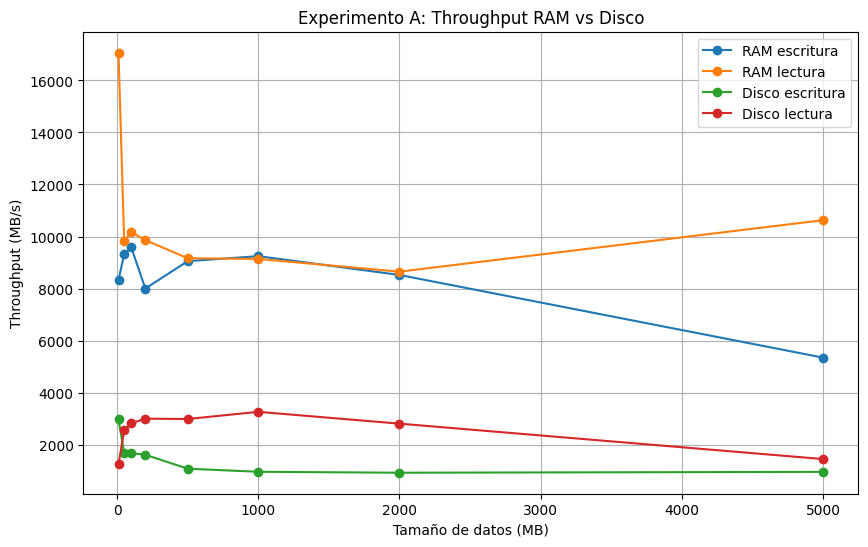

In [ ]:
# Gráfico de throughput (MB/s)
plt.figure(figsize=(10, 6))
plt.plot(df_results["size_mb"], df_results["ram_write_throughput_mb_s"], marker="o", label="RAM escritura")
plt.plot(df_results["size_mb"], df_results["ram_read_throughput_mb_s"], marker="o", label="RAM lectura")
plt.plot(df_results["size_mb"], df_results["disk_write_throughput_mb_s"], marker="o", label="Disco escritura")
plt.plot(df_results["size_mb"], df_results["disk_read_throughput_mb_s"], marker="o", label="Disco lectura")
plt.xlabel("Tamaño de datos (MB)")
plt.ylabel("Throughput (MB/s)")
plt.title("Experimento A: Throughput RAM vs Disco")
plt.legend()
plt.grid(True)
plt.savefig(vis_dir / "grafico_experimento_a_throughput.png")
plt.show()

## 8. Eliminar archivos temporales

In [ ]:
# Eliminar archivos .npy después del experimento
for size_mb in sizes_mb:
    file_path = datos_dir / f"array_{size_mb}MB.npy"
    if file_path.exists():
        file_path.unlink()

print("Archivos temporales eliminados.")

Archivos temporales eliminados.
